# Customer Analytics — Online Retail II

## Overview
Analysis of ~776K cleaned transactions (2009-2011) from a UK-based online retailer, 
focused on identifying customer value segments using RFM (Recency, Frequency, Monetary) analysis.

## Key Findings
- Total customers analyzed: ~5,861
- **Champions (469 customers)**: Recent, frequent, high-spending — the most valuable segment
- **At Risk (355 customers)**: Previously high-value customers who haven't purchased recently — 
  strong candidates for win-back campaigns
- **Lost (1,514 customers)**: Long inactive with low historical engagement
- Sales show [describe the seasonal pattern you saw in your monthly trend chart — e.g., "a spike in November, likely holiday shopping"]

## Recommendation
Prioritize a targeted re-engagement campaign for the "At Risk" segment, since they've historically 
shown high spending behavior and are more likely to respond to a win-back offer than "Lost" customers.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_online_retail.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,Tuesday


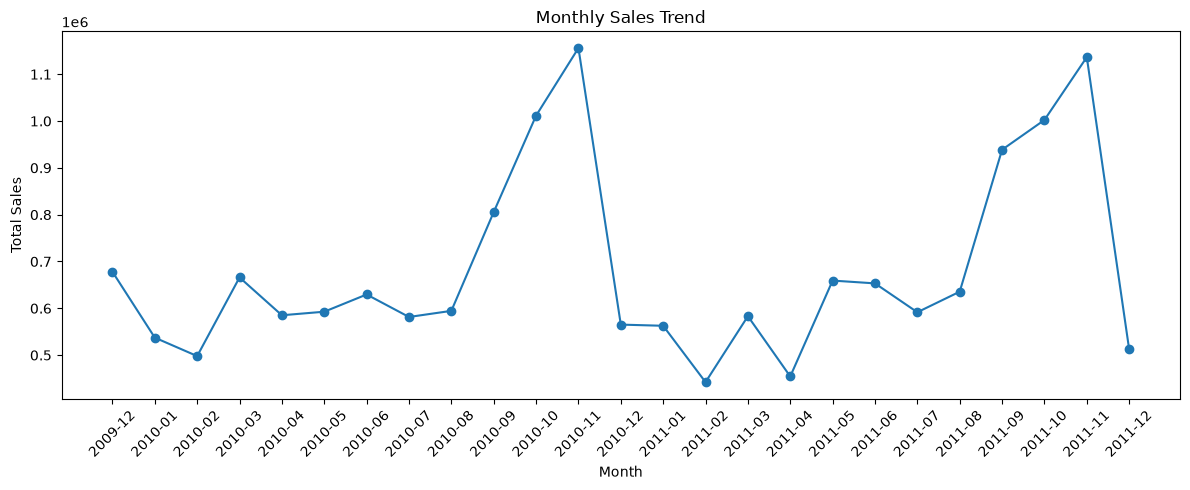

In [3]:
# Group by Year and Month to get total sales
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()

# Create a combined Year-Month label for plotting
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalPrice'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

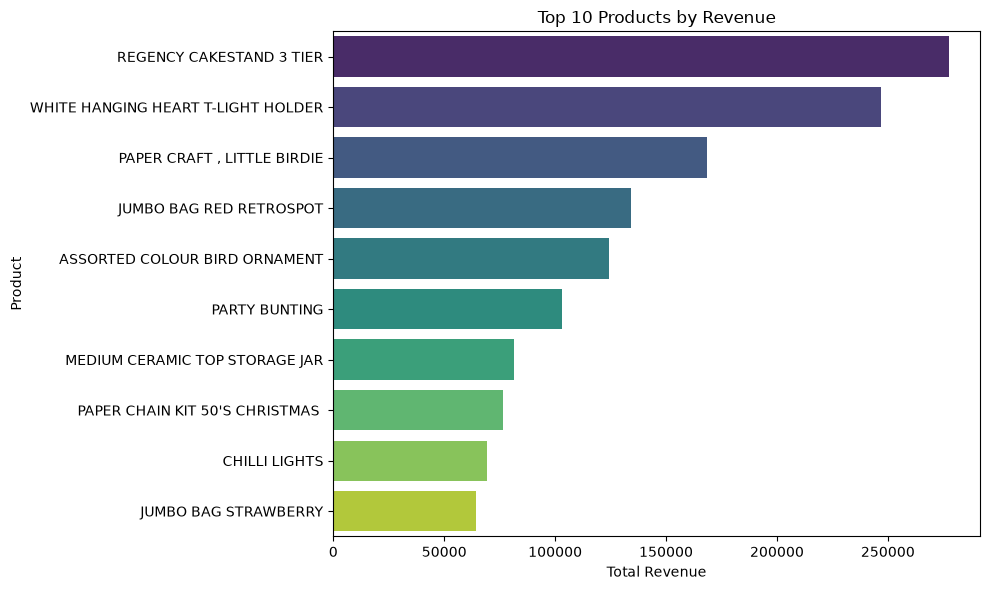

In [6]:
# Top 10 Products
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='viridis', legend=False)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [8]:
# Find top 10 customers by total spend
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

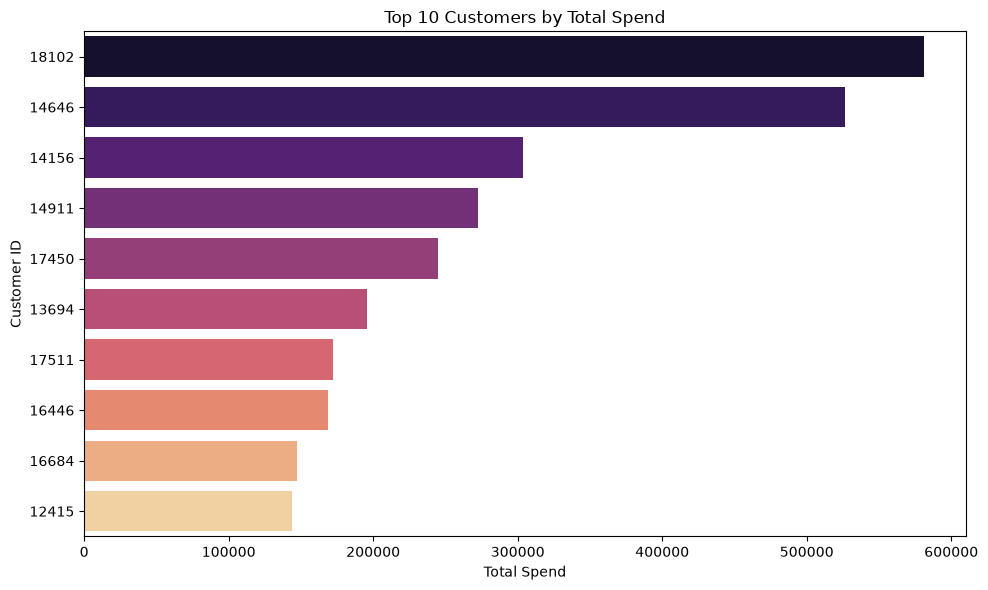

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), hue=top_customers.index.astype(str), palette='magma', legend=False)
plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Total Spend')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

In [11]:
# Convert InvoiceDate back to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [12]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [13]:
# Build the RFM table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                                        # Frequency
    'TotalPrice': 'sum'                                          # Monetary
}).reset_index()

# Rename columns for clarity
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,1658.40
3,12349,19,3,3678.69
4,12350,310,1,294.40


In [14]:
# Score Recency, Frequency, Monetary from 1 to 5 using quantiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,12,77556.46,2,5,5
1,12347,2,8,4921.53,5,4,5
2,12348,75,5,1658.40,3,4,4
3,12349,19,3,3678.69,5,3,5
4,12350,310,1,294.40,2,1,2


In [15]:
# Combine R, F, M scores into a single string
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Define a function to label segments based on score patterns
def segment_customer(row):
    if row['R_Score'] == 5 and row['F_Score'] == 5 and row['M_Score'] == 5:
        return 'Champions'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm['Segment'].value_counts()

Segment
Needs Attention    2064
Lost               1514
Loyal Customers    1008
Champions           469
New Customers       451
At Risk             355
Name: count, dtype: int64

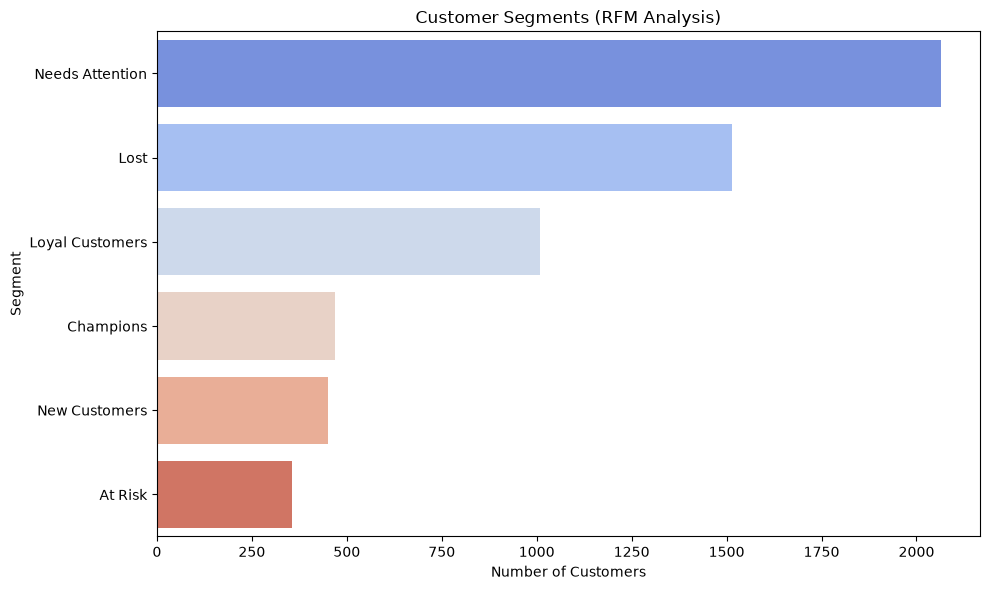

In [16]:
# Plot segment distribution
plt.figure(figsize=(10, 6))
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, hue=segment_counts.index, palette='coolwarm', legend=False)
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

In [17]:
# Save RFM segmentation results
rfm.to_csv('customer_segments_rfm.csv', index=False)
print("RFM segmentation saved successfully!")

RFM segmentation saved successfully!
